# E-Commerce Data Pipeline — Analytics & Insights
**Portfolio Project** | Real-Time Data Pipeline

---
This notebook connects to the SQLite data warehouse and generates business insights from the processed e-commerce dataset (1,000 products, 97 categories).

In [1]:
# ── Cell 1: Setup & Connect ──────────────────────────────────
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Connect
conn = sqlite3.connect('data/ecommerce_dw.db')
df   = pd.read_sql('SELECT * FROM fact_product_listing', conn)

print(f'Rows loaded : {len(df):,}')
print(f'Columns     : {list(df.columns)}')

Rows loaded : 1,000
Columns     : ['product_id', 'category_slug', 'seller_name', 'initial_price', 'final_price', 'discount', 'discount_amount', 'is_discounted', 'price_bucket', 'rating', 'ratings_count', 'ratings_tier', 'rating_x_count', 'title_word_count', 'has_seller']


In [2]:
# ── Cell 2: KPI Snapshot ─────────────────────────────────────
kpis = {
    'Total Products'       : f"{len(df):,}",
    'Avg Rating'           : f"{df['rating'].mean():.2f} / 5",
    'Avg Discount'         : f"{df['discount'].mean():.1f}%",
    'Avg Selling Price'    : f"INR {df['final_price'].mean():,.0f}",
    'Revenue Potential'    : f"INR {df['final_price'].sum():,.0f}",
    'Discounted Products'  : f"{df['is_discounted'].sum():,}",
    'Known Sellers'        : f"{df['has_seller'].sum():,}",
    'Categories'           : f"{df['category_slug'].nunique()}",
}

print('=' * 40)
print('       EXECUTIVE KPI SNAPSHOT')
print('=' * 40)
for k, v in kpis.items():
    print(f'  {k:<22} {v}')
print('=' * 40)

       EXECUTIVE KPI SNAPSHOT
  Total Products         1,000
  Avg Rating             3.62 / 5
  Avg Discount           53.8%
  Avg Selling Price      INR 1,706
  Revenue Potential      INR 1,706,096
  Discounted Products    1,000
  Known Sellers          699
  Categories             97


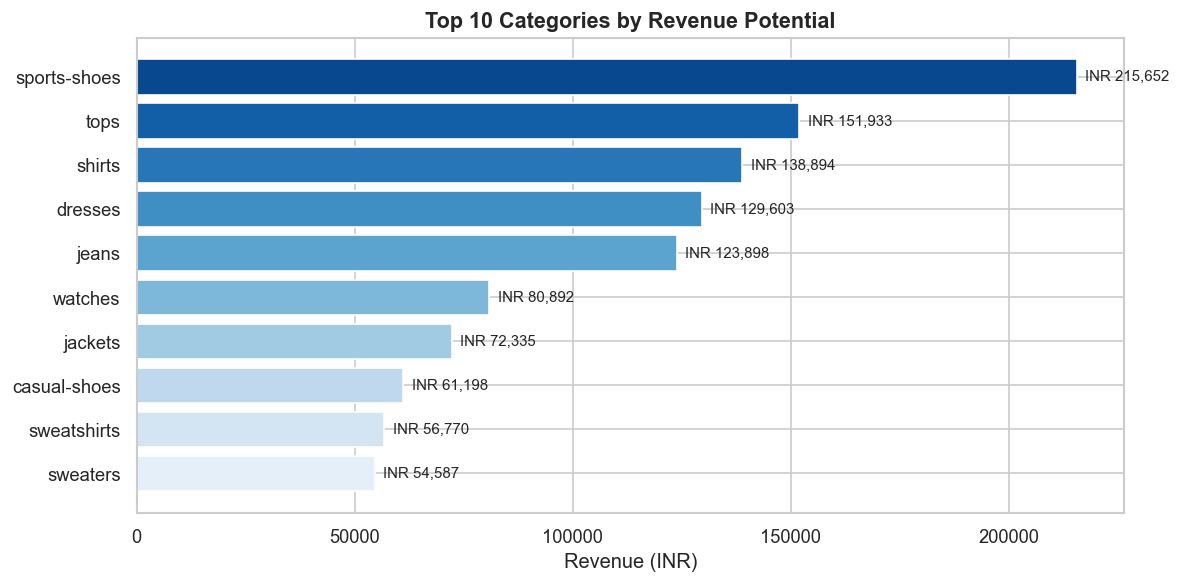

In [3]:
# ── Cell 3: Top 10 Categories by Revenue ─────────────────────
cat_rev = (
    df.groupby('category_slug')['final_price']
    .sum().sort_values(ascending=False).head(10)
    .reset_index()
)
cat_rev.columns = ['category', 'revenue']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_rev['category'], cat_rev['revenue'], color=sns.color_palette('Blues_r', 10))
ax.bar_label(bars, labels=[f'INR {v:,.0f}' for v in cat_rev['revenue']], padding=5, fontsize=9)
ax.set_title('Top 10 Categories by Revenue Potential', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (INR)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('data/chart_revenue_by_category.png', bbox_inches='tight')
plt.show()

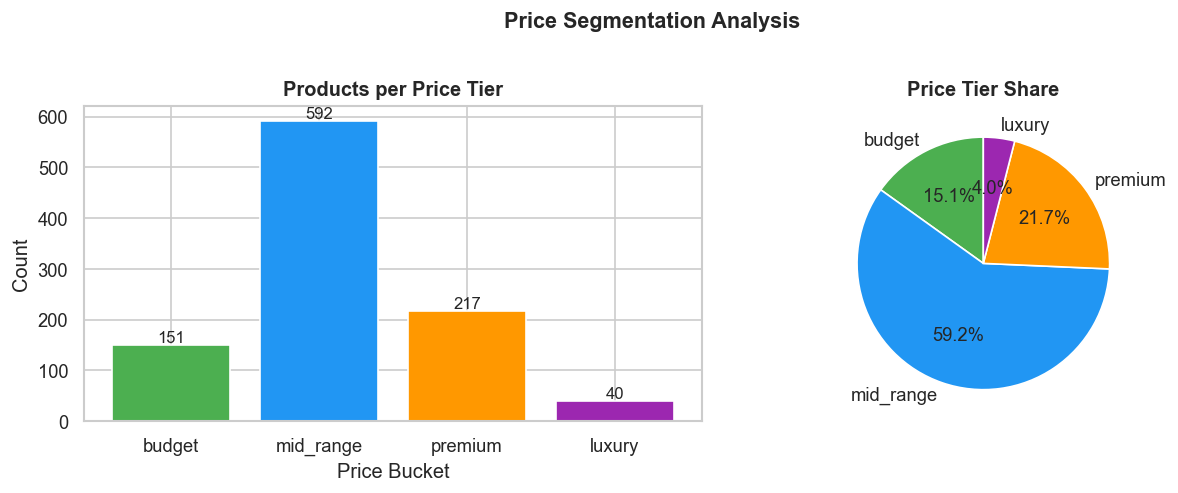

In [4]:
# ── Cell 4: Price Bucket Distribution ────────────────────────
bucket_order = ['budget', 'mid_range', 'premium', 'luxury']
bucket_counts = df['price_bucket'].value_counts().reindex(bucket_order)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
axes[0].bar(bucket_counts.index, bucket_counts.values, color=colors)
axes[0].set_title('Products per Price Tier', fontweight='bold')
axes[0].set_xlabel('Price Bucket')
axes[0].set_ylabel('Count')
for i, v in enumerate(bucket_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(bucket_counts.values, labels=bucket_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Price Tier Share', fontweight='bold')

plt.suptitle('Price Segmentation Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/chart_price_buckets.png', bbox_inches='tight')
plt.show()

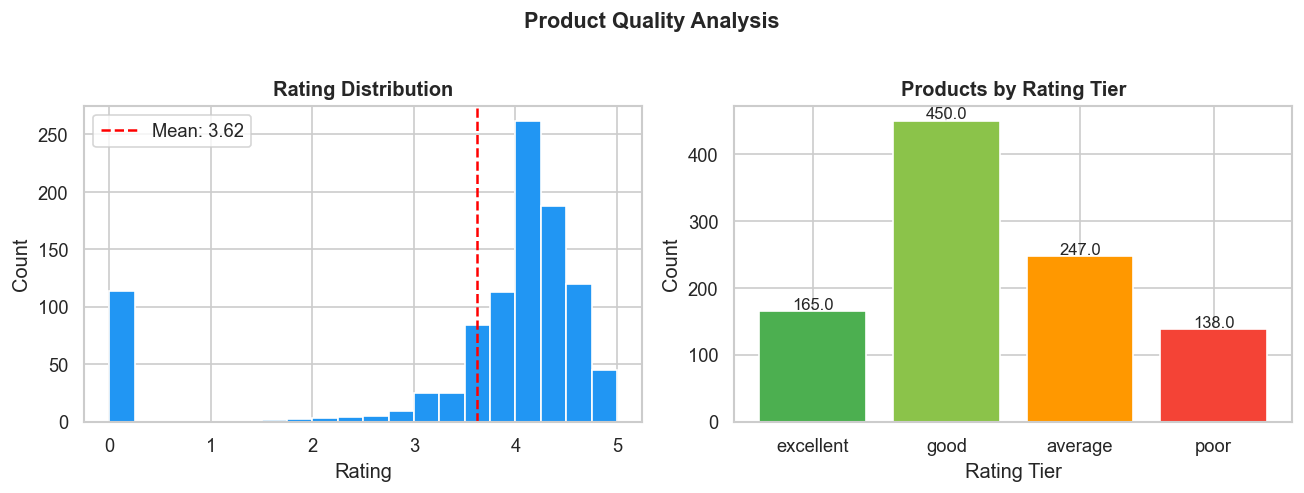

In [5]:
# ── Cell 5: Rating Distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram
axes[0].hist(df['rating'].dropna(), bins=20, color='#2196F3', edgecolor='white')
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['rating'].mean():.2f}")
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Tier bar
tier_order = ['excellent', 'good', 'average', 'poor', 'unknown']
tier_colors = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336', '#9E9E9E']
tier_counts = df['ratings_tier'].value_counts().reindex(tier_order).dropna()
axes[1].bar(tier_counts.index, tier_counts.values, color=tier_colors[:len(tier_counts)])
axes[1].set_title('Products by Rating Tier', fontweight='bold')
axes[1].set_xlabel('Rating Tier')
axes[1].set_ylabel('Count')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontsize=10)

plt.suptitle('Product Quality Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/chart_ratings.png', bbox_inches='tight')
plt.show()

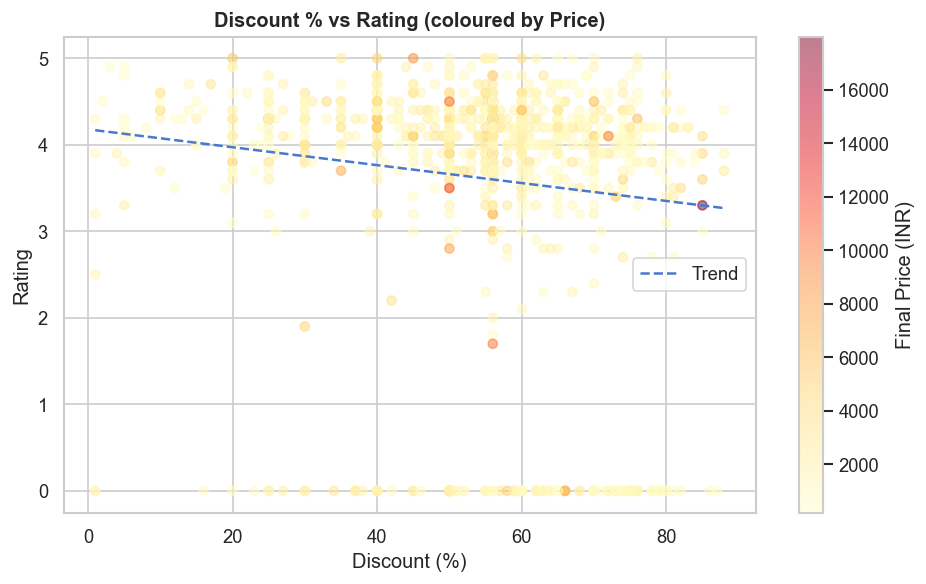

Correlation between Discount and Rating: -0.127


In [6]:
# ── Cell 6: Discount vs Rating Correlation ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df['discount'], df['rating'],
    c=df['final_price'], cmap='YlOrRd',
    alpha=0.5, s=30
)
plt.colorbar(scatter, ax=ax, label='Final Price (INR)')
ax.set_title('Discount % vs Rating (coloured by Price)', fontweight='bold')
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Rating')

# Trend line
import numpy as np
mask = df['discount'].notna() & df['rating'].notna()
z = np.polyfit(df.loc[mask,'discount'], df.loc[mask,'rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['discount'].min(), df['discount'].max(), 100)
ax.plot(x_line, p(x_line), 'b--', linewidth=1.5, label='Trend')
ax.legend()

plt.tight_layout()
plt.savefig('data/chart_discount_vs_rating.png', bbox_inches='tight')
plt.show()

corr = df[['discount','rating']].corr().iloc[0,1]
print(f'Correlation between Discount and Rating: {corr:.3f}')

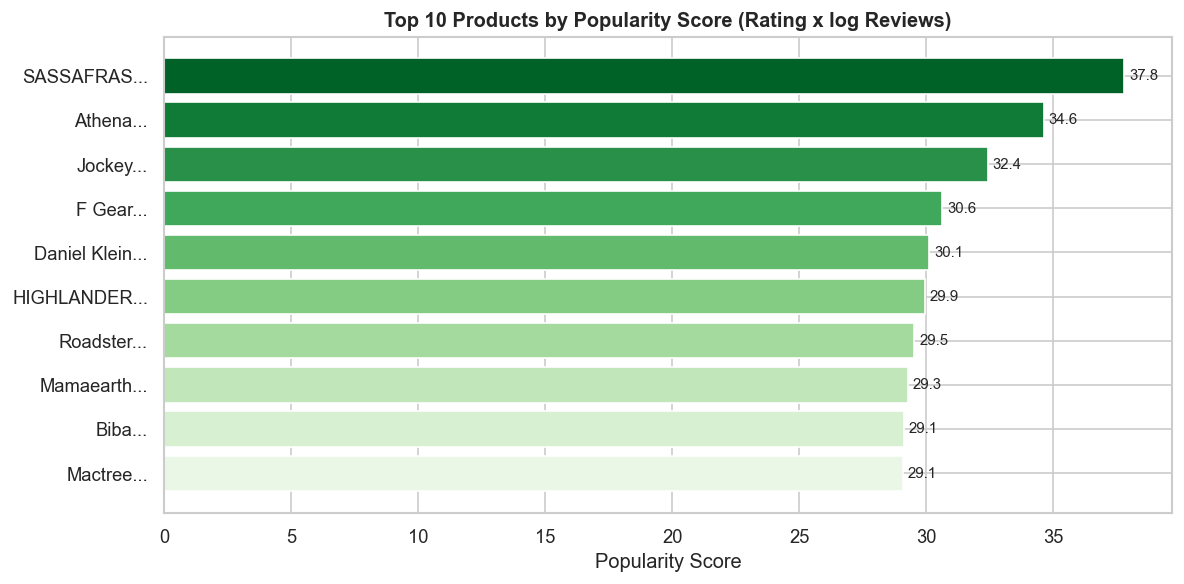

In [7]:
# ── Cell 7: Top 10 Products by Popularity Score ───────────────
top_products = pd.read_sql("""
    SELECT p.title, f.category_slug, f.rating,
           f.ratings_count, f.final_price, f.rating_x_count
    FROM fact_product_listing f
    JOIN dim_product p ON f.product_id = p.product_id
    ORDER BY f.rating_x_count DESC
    LIMIT 10
""", conn)

top_products['short_title'] = top_products['title'].str[:35] + '...'

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_products['short_title'], top_products['rating_x_count'],
               color=sns.color_palette('Greens_r', 10))
ax.bar_label(bars, labels=[f"{v:.1f}" for v in top_products['rating_x_count']], padding=3, fontsize=9)
ax.set_title('Top 10 Products by Popularity Score (Rating x log Reviews)', fontweight='bold')
ax.set_xlabel('Popularity Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('data/chart_top_products.png', bbox_inches='tight')
plt.show()

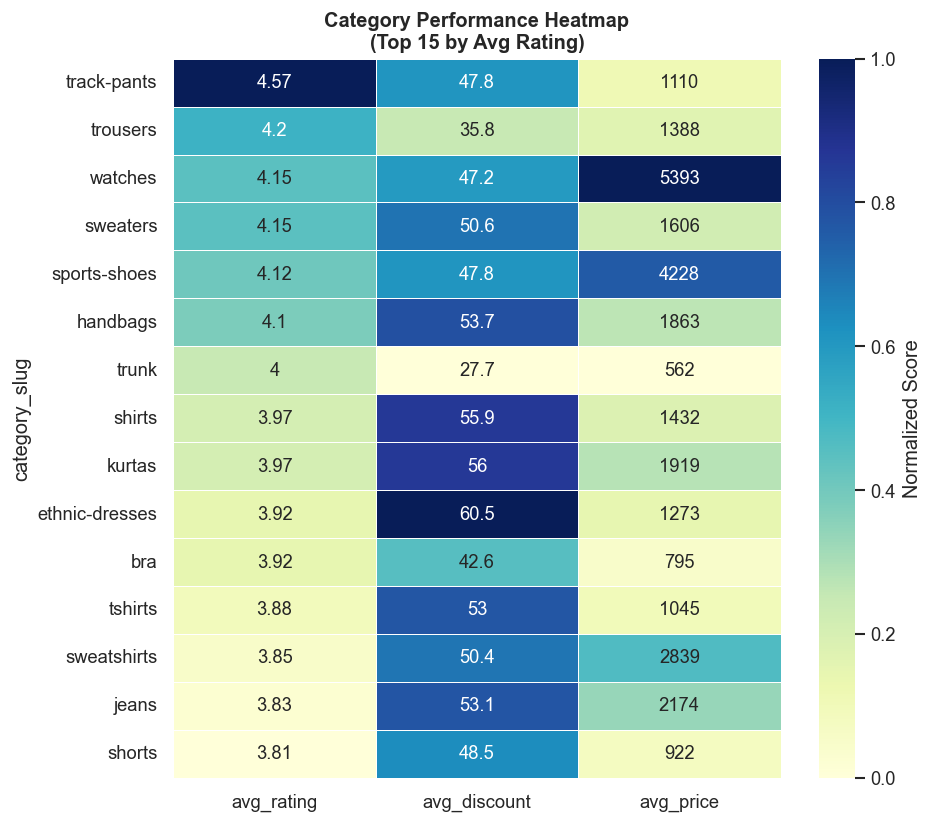

In [8]:
# ── Cell 8: Category Rating Heatmap ──────────────────────────
cat_metrics = pd.read_sql("""
    SELECT category_slug,
           ROUND(AVG(rating),2)      as avg_rating,
           ROUND(AVG(discount),1)    as avg_discount,
           ROUND(AVG(final_price),0) as avg_price,
           COUNT(*)                  as products
    FROM fact_product_listing
    GROUP BY category_slug
    HAVING COUNT(*) >= 5
    ORDER BY avg_rating DESC
    LIMIT 15
""", conn)

heatmap_data = cat_metrics.set_index('category_slug')[['avg_rating','avg_discount','avg_price']]
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(heatmap_norm, annot=heatmap_data, fmt='g', cmap='YlGnBu',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Score'})
ax.set_title('Category Performance Heatmap\n(Top 15 by Avg Rating)', fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('data/chart_category_heatmap.png', bbox_inches='tight')
plt.show()

In [9]:
# ── Cell 9: Summary ──────────────────────────────────────────
print('Charts saved:')
import os
charts = [f for f in os.listdir('data') if f.endswith('.png')]
for c in charts:
    print(f'  data/{c}')

conn.close()
print('\nNotebook complete!')

Charts saved:
  data/chart_category_heatmap.png
  data/chart_discount_vs_rating.png
  data/chart_price_buckets.png
  data/chart_ratings.png
  data/chart_revenue_by_category.png
  data/chart_top_products.png

Notebook complete!
